In [1]:
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('features/Descriptors/Train_2d_3d_all_descriptors.csv')

/tmp/ipykernel_3976185/2702917275.py:1: DtypeWarning: Columns (1275,1277,1280,1285,1292,1298,1304,1354,1356,1359,1364,1371,1377,1383,1579,1580,1581,1583,1584,1590,1595,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('features/Descriptors/Train_2d_3d_all_descriptors.csv')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.435194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 627870
[LightGBM] [Info] Number of data points in the train set: 5568, number of used features: 2842
[LightGBM] [Info] Start training from score -5.745541


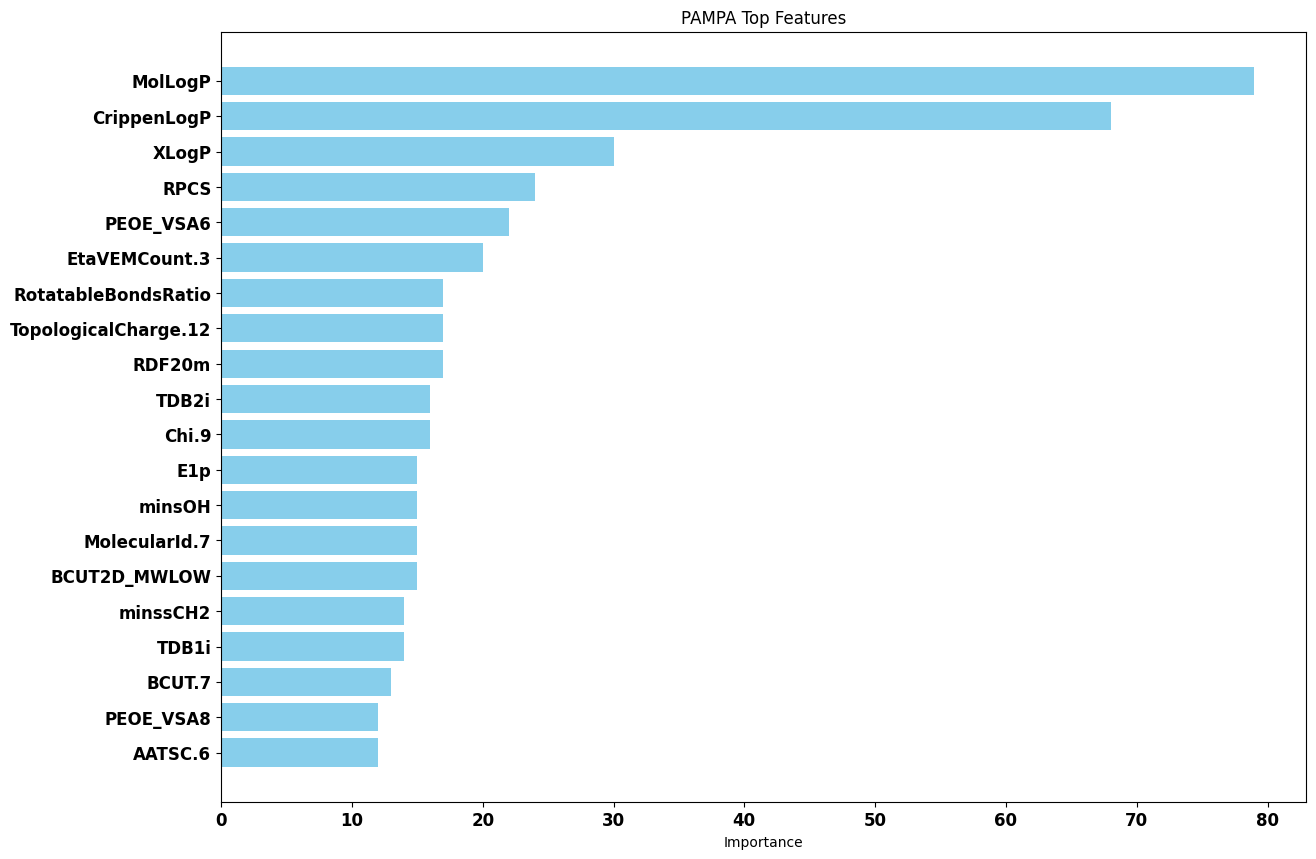

In [3]:
X_train = df1.drop(columns=['ID', 'SMILES', 'Permeability'])
X_train = X_train.select_dtypes(include=['number'])
y_train = df1['Permeability']

lgb_model = lgb.LGBMRegressor(objective='regression',metric='rmse',boosting_type='gbdt',num_leaves=31,learning_rate=0.05,random_state=101)
lgb_model.fit(X_train, y_train)

lgb_importance_all = lgb_model.feature_importances_
lgb_feature_importance_df_all = pd.DataFrame({'Feature': X_train.columns, 'Importance': lgb_importance_all})
lgb_top_features_all = lgb_feature_importance_df_all.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(14, 10))
plt.barh(lgb_top_features_all['Feature'], lgb_top_features_all['Importance'], color='skyblue')

plt.yticks(fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')

plt.xlabel('Importance')
plt.title('PAMPA Top Features')
plt.gca().invert_yaxis()
save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/imp_features_plot_.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

In [4]:
lgb_feature_importance_df_all.to_csv('Results/feature_analysis/Important_desc_all.csv')

In [5]:
print("Top 20 Features - LGBMRegressor:")
print(lgb_top_features_all)

Top 20 Features - LGBMRegressor:
                   Feature  Importance
130                MolLogP          79
2292           CrippenLogP          68
3085                 XLogP          30
3201                  RPCS          24
57               PEOE_VSA6          22
1265         EtaVEMCount.3          20
1582   RotatableBondsRatio          17
1599  TopologicalCharge.12          17
3260                RDF20m          17
3149                 TDB2i          16
1017                 Chi.9          16
3495                   E1p          15
2610                minsOH          15
1415         MolecularId.7          15
19            BCUT2D_MWLOW          15
2585              minssCH2          14
3148                 TDB1i          14
863                 BCUT.7          13
59               PEOE_VSA8          12
562                AATSC.6          12


In [6]:
df1_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Test_2d_3d_all_descriptors.csv')

/tmp/ipykernel_3976185/347469562.py:1: DtypeWarning: Columns (1275,1277,1292,1298,1354,1356,1371,1377,1579,1580,1581,1583,1584,1595,1596,1597) have mixed types. Specify dtype option on import or set low_memory=False.
  df1_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Descriptors/Test_2d_3d_all_descriptors.csv')


In [7]:
def top_features(df1, top_features):
   
    common_cols = ['ID', 'SMILES', 'Permeability']
    df = df1[common_cols + [col for col in top_features if col in df1.columns]]
    
    return df

In [8]:
df_train_all = top_features(df1, lgb_top_features_all['Feature'].tolist())
df_train_all.head(10)

,ID,SMILES,Permeability,MolLogP,CrippenLogP,XLogP,RPCS,PEOE_VSA6,EtaVEMCount.3,RotatableBondsRatio,...,Chi.9,E1p,minsOH,MolecularId.7,BCUT2D_MWLOW,minssCH2,TDB1i,BCUT.7,PEOE_VSA8,AATSC.6
0,915,CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...,-7.00,5.4834,5.48340,11.490,0.000000,186.921996,0.624016,0.198473,...,0.107570,0.459830,11.634439,0.244556,9.935395,-0.921018,185.955648,1.193304,74.638010,0.002817
1,888,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...,-7.00,6.8310,6.83100,10.250,0.000000,183.789212,0.630081,0.232558,...,0.296431,0.498664,11.568900,0.237439,9.949304,-0.917417,186.593937,1.193914,90.601182,0.002983
2,593,C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...,-7.00,5.1858,5.08349,10.960,0.000000,190.564713,0.630000,0.207692,...,0.130250,0.458043,0.000000,0.278572,9.957360,-0.861433,186.346230,1.225224,101.698932,0.002773
3,916,CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...,-7.00,4.8504,4.85040,9.243,0.253531,164.016813,0.626016,0.190476,...,0.084889,0.556060,11.446968,0.253144,9.948088,-0.795571,186.091252,1.193873,88.230438,0.002707
4,900,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...,-7.00,5.8121,5.81210,10.212,0.000000,184.285109,0.623984,0.246032,...,0.084889,0.527799,11.538240,0.253792,9.936220,-0.873111,186.181023,1.193878,82.312532,0.002738
5,911,CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1cc...,-6.96,4.5151,4.51510,7.516,0.000000,173.903013,0.630165,0.192000,...,0.136028,0.444749,11.318437,0.256961,9.947480,-0.930435,186.663353,1.193874,86.708315,0.002858
6,589,CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@H]...,-5.89,6.3427,6.34270,11.133,0.000000,190.564713,0.626016,0.218750,...,0.130250,0.481992,0.000000,0.252681,9.957323,-0.844363,185.567635,1.225224,81.058831,0.002824
7,912,CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...,-7.00,5.0971,5.09710,9.655,0.019310,163.839473,0.627083,0.203252,...,0.113348,0.568965,11.402983,0.258964,9.944220,-0.889778,186.652764,1.193910,80.287493,0.003100
8,898,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)N(C)C(=O)[C...,-6.96,4.8511,4.85110,9.169,0.051629,157.418652,0.631250,0.217742,...,0.220202,0.495739,11.509698,0.260121,9.947464,-0.933855,186.853644,1.193911,79.784578,0.003052
9,595,CC(C)C[C@@H]1NC(=O)[C@H](Cc2cccnc2)NC(=O)[C@H]...,-7.00,6.2485,6.24850,9.966,0.004066,196.631080,0.628049,0.193798,...,0.147819,0.454380,0.000000,0.252900,9.957273,-0.863081,185.622275,1.225224,99.873340,0.002925


In [9]:
df_test_all = top_features(df1_test, lgb_top_features_all['Feature'].tolist())
df_test_all.head(10)

,ID,SMILES,Permeability,MolLogP,CrippenLogP,XLogP,RPCS,PEOE_VSA6,EtaVEMCount.3,RotatableBondsRatio,...,Chi.9,E1p,minsOH,MolecularId.7,BCUT2D_MWLOW,minssCH2,TDB1i,BCUT.7,PEOE_VSA8,AATSC.6
0,908,CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...,-7.00,6.3199,6.3199,10.264,0.000000,200.592130,0.625000,0.223077,...,0.136028,0.518092,11.363584,0.247157,9.936577,-0.932382,186.322114,1.193881,86.708315,0.002809
1,923,CC[C@H](C)[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H](...,-7.00,4.9450,4.9450,9.667,0.027156,156.590160,0.628049,0.174603,...,0.084889,0.508567,11.570545,0.253686,9.955648,-0.836449,186.150135,1.193915,82.312532,0.002756
2,897,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-7.00,4.5441,4.5441,9.469,0.000000,200.769470,0.625000,0.230159,...,0.107570,0.000000,11.254097,0.254236,9.947726,-0.945263,0.000000,1.193910,74.638010,0.003123
3,587,CC(C)C[C@@H]1NC(=O)[C@H](Cc2c[nH]cn2)NC(=O)[C@...,-6.74,5.5766,5.0947,10.338,0.044254,190.564713,0.633197,0.195312,...,0.145465,0.432372,0.000000,0.271278,9.957371,-0.864915,186.165922,1.225224,93.676496,0.002901
4,921,CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)N(C)C(=O)[...,-5.54,3.1222,3.1222,9.346,0.054757,150.169339,0.630252,0.155738,...,0.084889,0.566432,10.767921,0.261996,9.938433,-1.062878,186.328229,1.193878,82.312532,0.002984
5,218,CC(C)C[C@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)N[C@@H...,-6.80,5.3805,5.3805,8.616,0.000000,176.717239,0.631250,0.192000,...,0.130250,0.435299,11.682911,0.244125,9.964686,-0.901415,185.668956,1.209146,102.201847,0.002781
6,297,CC[C@H](C)[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C)C(=...,-6.62,5.0383,5.0383,8.692,0.029012,183.138061,0.630252,0.193548,...,0.130250,0.419303,11.470355,0.245304,9.950488,-0.944930,185.651617,1.193899,95.154175,0.002878
7,899,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,-6.33,4.5863,4.5863,9.720,0.000000,143.889734,0.626087,0.247863,...,0.148792,0.000000,11.159704,0.271479,9.940193,-0.739145,0.000000,1.193879,74.885879,0.002815
8,588,CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@@H...,-5.96,4.2378,4.2378,8.532,0.000000,146.385404,0.634783,0.200000,...,0.216834,0.439105,0.000000,0.270585,9.959669,-0.828332,186.401771,1.225224,74.135094,0.003041
9,514,CC(C)C[C@H]1C(=O)N[C@@H]([C@@H](C)O)C(=O)N(C)[...,-6.70,3.5274,3.5274,7.104,0.016805,176.717239,0.632609,0.183333,...,0.130250,0.501148,11.463357,0.252921,9.968256,-0.903421,185.984731,1.201042,88.106503,0.003148


In [10]:
def add_label_column(df):
    df = df.copy()
    df['Label'] = (df['Permeability'] >= -6).astype(int)
    return df

In [11]:
train_df_labeled = add_label_column(df_train_all)
test_df_labeled = add_label_column(df_test_all)
print(train_df_labeled.head(10))
print(test_df_labeled.head(10))

    ID                                             SMILES  Permeability  \
0  915  CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...         -7.00   
1  888  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...         -7.00   
2  593  C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...         -7.00   
3  916  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...         -7.00   
4  900  CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...         -7.00   
5  911  CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1cc...         -6.96   
6  589  CC(C)C[C@@H]1NC(=O)[C@H](CCCCN(C)C)NC(=O)[C@H]...         -5.89   
7  912  CC[C@H](C)[C@@H]1NC(=O)[C@H](CC(C)C)NC(=O)[C@H...         -7.00   
8  898  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)N(C)C(=O)[C...         -6.96   
9  595  CC(C)C[C@@H]1NC(=O)[C@H](Cc2cccnc2)NC(=O)[C@H]...         -7.00   

   MolLogP  CrippenLogP   XLogP      RPCS   PEOE_VSA6  EtaVEMCount.3  \
0   5.4834      5.48340  11.490  0.000000  186.921996       0.624016   
1   6.8310      6.83100  10.25

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

In [13]:
def boxplots_diff_labels(df, features, label_col='Label', save_path='feature_box_plot.png'):
    num_features = len(features)
    cols = 5  
    rows = (num_features + cols - 1) // cols  

    plt.figure(figsize=(cols * 8, rows * 7))
    sns.set_style("whitegrid")

    label_mapping = {0: "Non-Permeable", 1: "Permeable"}

    for idx, feature in enumerate(features, 1):
        plt.subplot(rows, cols, idx)
        ax = sns.boxplot(x=label_col, y=feature, data=df, hue=label_col, palette="Set2", legend=False)

        plt.title(f'{feature}', fontsize=16, fontweight='600', pad=12)
        plt.xlabel("Permeability", fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.xticks(ticks=[0, 1], labels=[label_mapping[0], label_mapping[1]], fontsize=11)
        plt.yticks(fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()



def ttest_feature_tests(df, label_col='Label', feature_cols=None, save_path='ttest.csv'):
   
    
    if feature_cols is None:
        feature_cols = [col for col in df.columns if col not in ['ID', 'SMILES', 'Permeability', label_col]]

    label_0_data = df[df[label_col] == 0]
    label_1_data = df[df[label_col] == 1]

    results = []
    alpha = 0.05 
    for feature in feature_cols:
        class0_vals = label_0_data[feature].dropna()
        class1_vals = label_1_data[feature].dropna()
        
        
        t_stat, p_val = stats.ttest_ind(class0_vals, class1_vals, equal_var=False)
        
        print(f"Feature: {feature}")
        print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4f}")
        
        # Interpretation
        if p_val < alpha:
            print("Result: Reject the null hypothesis - significant difference between the two groups.\n")
        else:
            print("Result: Fail to reject the null hypothesis - no significant difference between the two groups.\n")
        
        results.append({'Feature': feature, 't-statistic': t_stat, 'p-value': p_val})

    results_df = pd.DataFrame(results).sort_values('p-value')
    results_df.to_csv(save_path, index=False)
    return results_df



def plot_top_feature_correlations(df, label_col='Label', permeability_col='Permeability',
                                   top_desc_features=None, save_path='feature_correlation_plot.png'):
    

    features = top_desc_features + [permeability_col, label_col]
    df_sub = df[features]

    corr_label0 = df_sub[df_sub[label_col] == 0].corr()[permeability_col].drop([permeability_col, label_col])
    corr_label1 = df_sub[df_sub[label_col] == 1].corr()[permeability_col].drop([permeability_col, label_col])

    corr_df = pd.DataFrame({
        'Feature': corr_label0.index,
        'Corr_Label_0': corr_label0.values,
        'Corr_Label_1': corr_label1.reindex(corr_label0.index).values
    })

    print("\nTop Features Correlation with Permeability by Label:\n")
    print(corr_df.to_string(index=False))

    plt.style.use('default')
    sns.set_context('talk')
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'axes.titleweight': 'bold',
        'axes.labelweight': 'bold'
    })

    fig, ax = plt.subplots(figsize=(16, 14))

    bar_height = 0.35
    n_features = len(corr_df)
    y_indexes = np.arange(n_features)

    colors_label0 = ['red'] * n_features
    colors_label1 = ['blue'] * n_features

    ax.barh(y_indexes + bar_height/2, corr_df['Corr_Label_0'], height=bar_height,
            color=colors_label0, label='Non-Permeable peptides', align='center')

    ax.barh(y_indexes - bar_height/2, corr_df['Corr_Label_1'], height=bar_height,
            color=colors_label1, label='Permeable peptides', align='center')

    ax.set_yticks(y_indexes)
    ax.set_yticklabels(corr_df['Feature'], fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    ax.set_xlabel('Correlation with Permeability', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_title('Features Correlation with Permeability', fontsize=24, fontweight='bold', pad=25)

    ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.yaxis.grid(False)
    ax.invert_yaxis()

    for spine in ['bottom', 'left', 'top', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1)

    ax.tick_params(axis='both', which='major',
                   direction='out',
                   length=6,
                   width=1,
                   color='black',
                   labelsize=12)

    ax.legend(frameon=False, fontsize=16, loc='upper right', borderaxespad=0.5)

    plt.tight_layout()

  
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

    return corr_df


In [14]:

feature_cols_train = [col for col in train_df_labeled.columns if col not in ['ID', 'SMILES', 'Permeability', 'Label']]

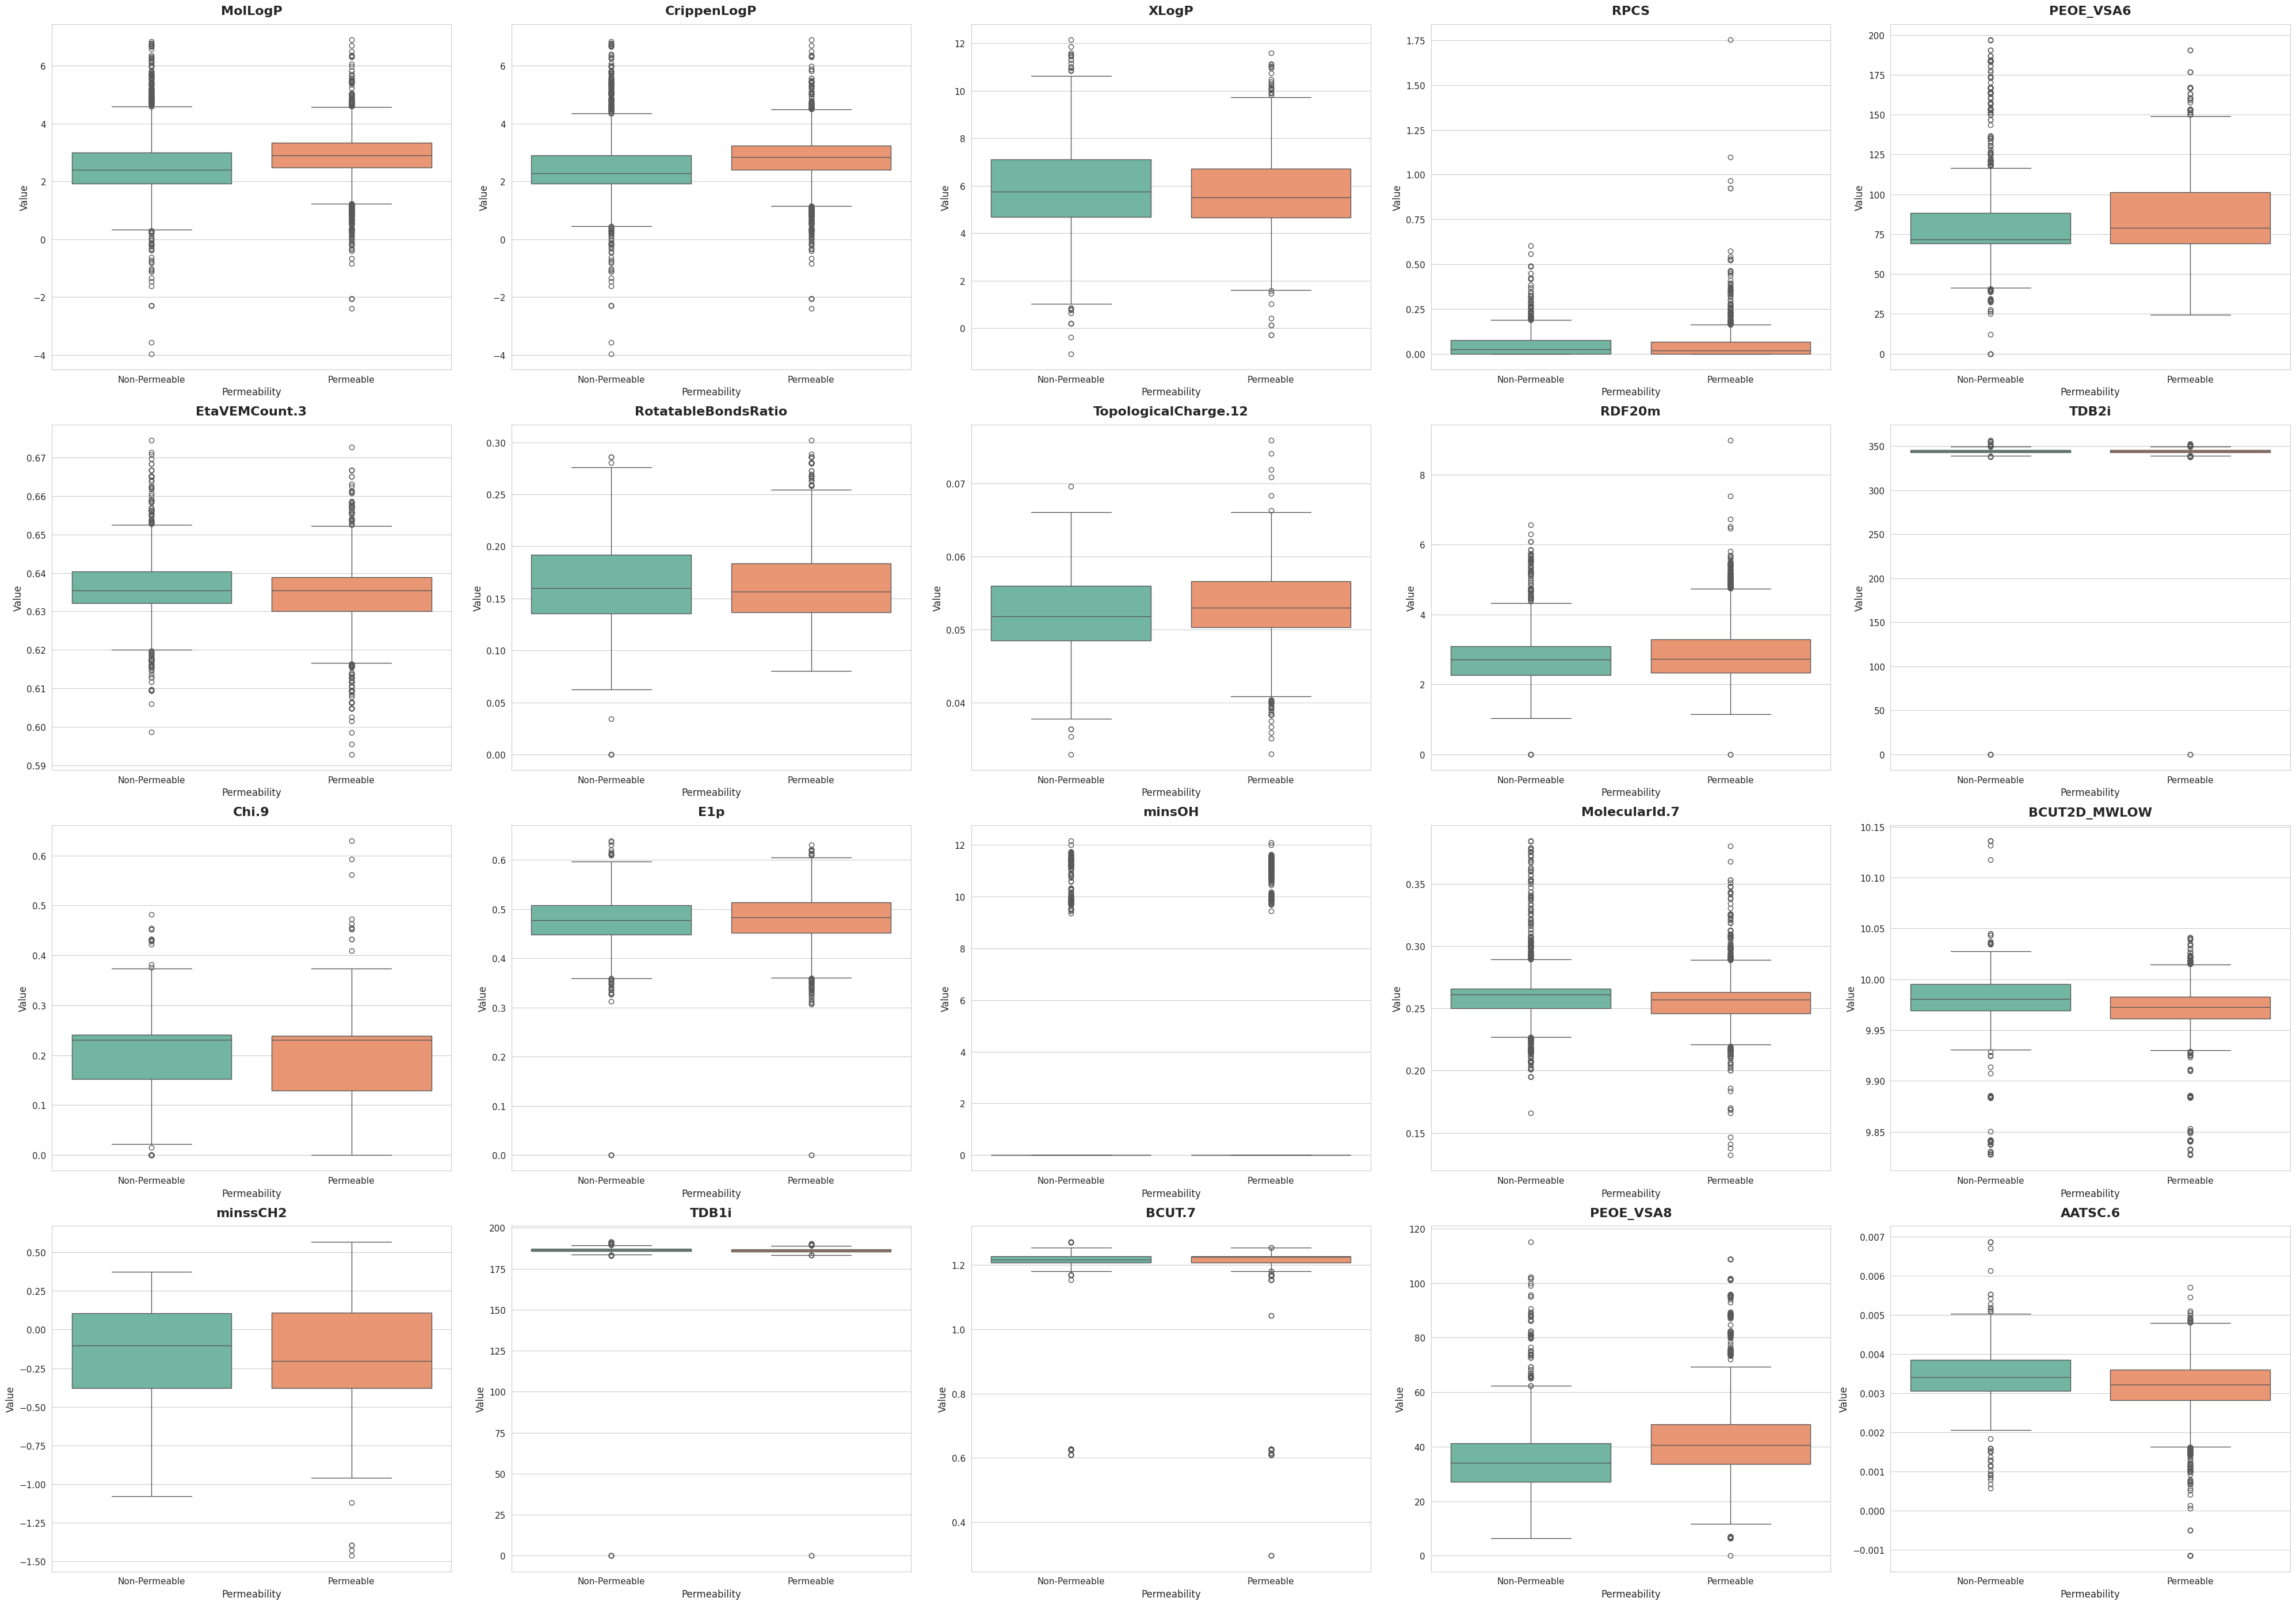

In [15]:
boxplots_diff_labels(train_df_labeled, feature_cols_train, label_col='Label', save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/desc_train_box_plot.png')


Top Features Correlation with Permeability by Label:

             Feature  Corr_Label_0  Corr_Label_1
             MolLogP      0.100395     -0.120563
         CrippenLogP      0.079127     -0.091468
               XLogP      0.056319     -0.013444
                RPCS     -0.054841     -0.051674
           PEOE_VSA6      0.088072      0.183359
       EtaVEMCount.3     -0.002347     -0.158469
 RotatableBondsRatio     -0.130255     -0.049270
TopologicalCharge.12     -0.077637      0.253220
              RDF20m     -0.091432      0.388445
               TDB2i      0.007430      0.083415
               Chi.9      0.246425     -0.515097
                 E1p      0.100557      0.100176
              minsOH     -0.146336      0.548962
       MolecularId.7     -0.107704      0.097574
        BCUT2D_MWLOW     -0.059875     -0.159565
            minssCH2      0.186564     -0.314260
               TDB1i      0.006879      0.042980
              BCUT.7      0.128965     -0.007292
           PEO

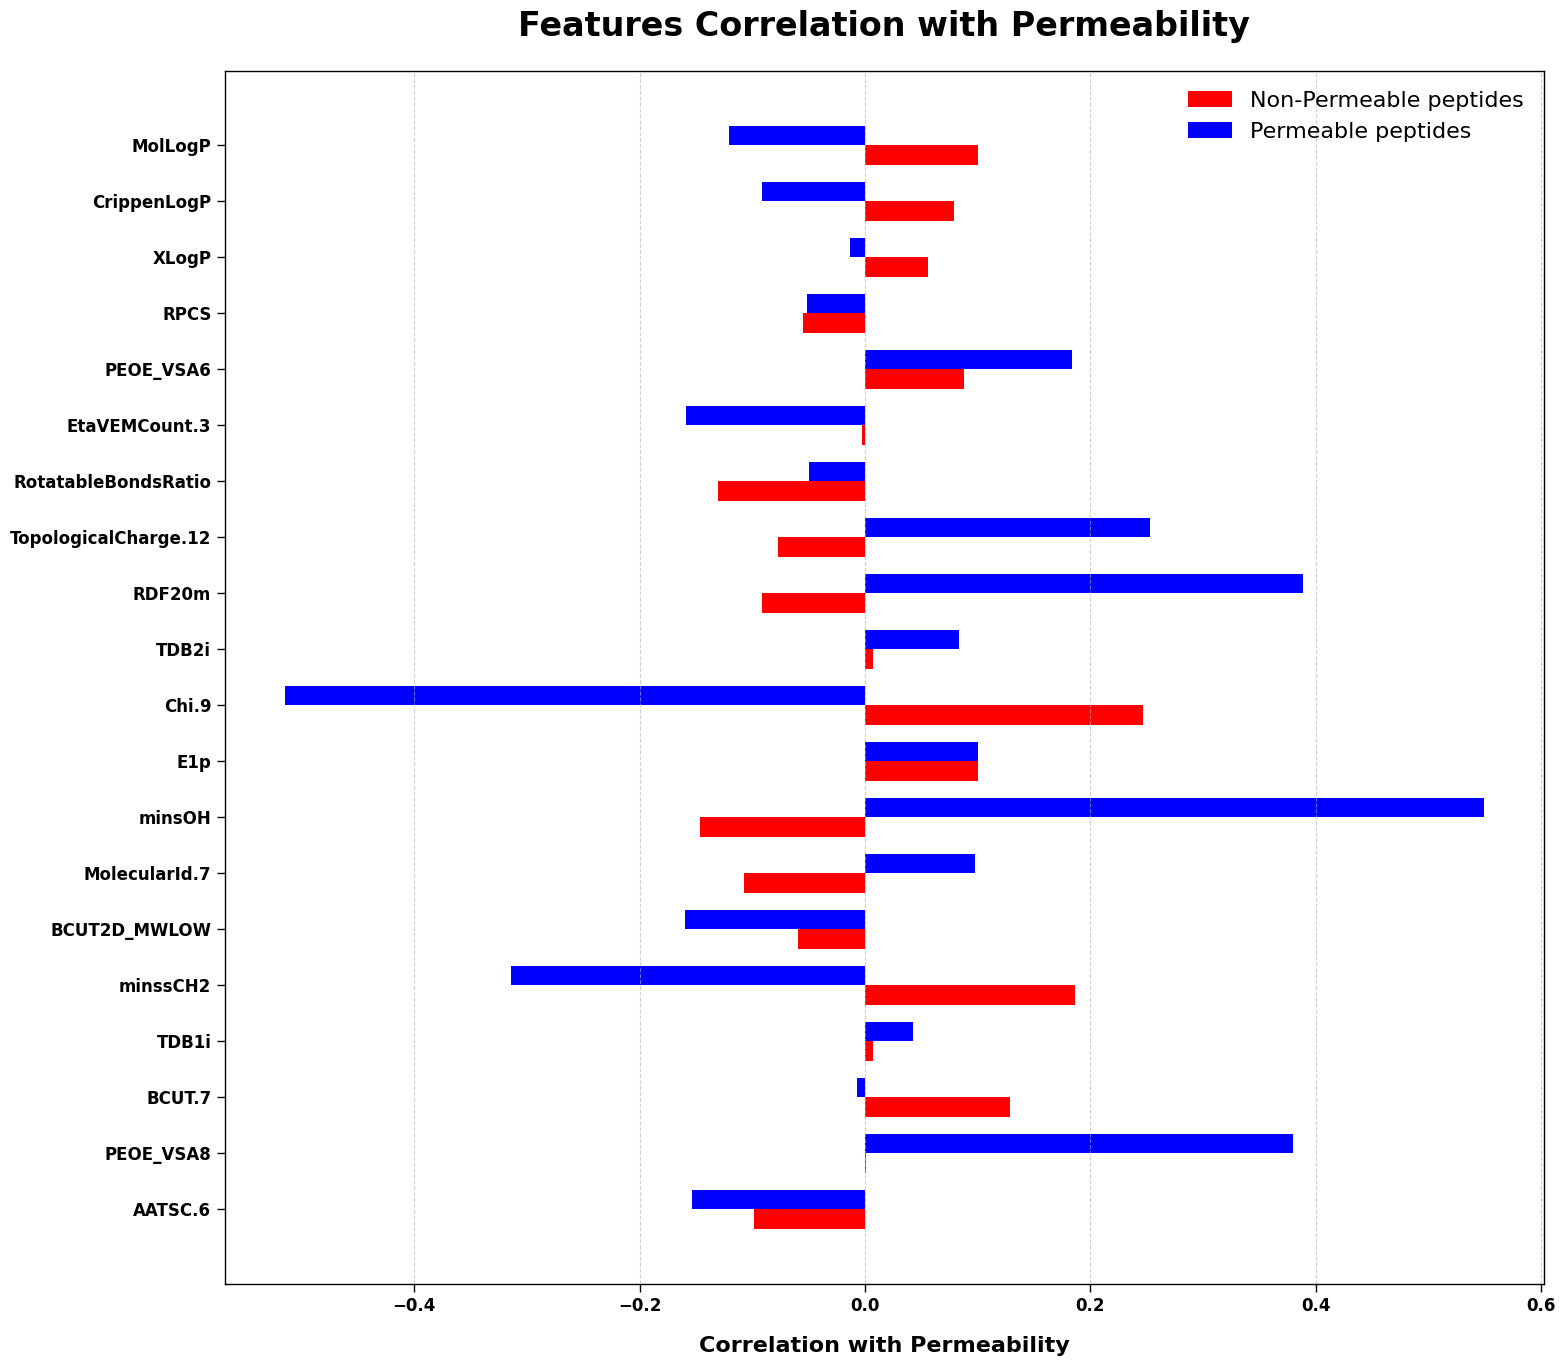

In [16]:
lgb_top_features_list = lgb_top_features_all['Feature'].to_list()
corr_df = plot_top_feature_correlations(
    train_df_labeled,
    label_col='Label',
    permeability_col='Permeability',
    top_desc_features=lgb_top_features_list,
    save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/desc_train_corr_plot.png'
    
)

In [17]:
feature_cols_train

['MolLogP',
 'CrippenLogP',
 'XLogP',
 'RPCS',
 'PEOE_VSA6',
 'EtaVEMCount.3',
 'RotatableBondsRatio',
 'TopologicalCharge.12',
 'RDF20m',
 'TDB2i',
 'Chi.9',
 'E1p',
 'minsOH',
 'MolecularId.7',
 'BCUT2D_MWLOW',
 'minssCH2',
 'TDB1i',
 'BCUT.7',
 'PEOE_VSA8',
 'AATSC.6']

In [18]:
ttest_df_train = ttest_feature_tests(train_df_labeled, label_col='Label', feature_cols=feature_cols_train, save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/pampa_train_ttest.csv')
print(ttest_df_train)

Feature: MolLogP
T-Statistic: -9.7846, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: CrippenLogP
T-Statistic: -10.0574, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: XLogP
T-Statistic: 2.4740, P-Value: 0.0134
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: RPCS
T-Statistic: 2.9379, P-Value: 0.0033
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: PEOE_VSA6
T-Statistic: -8.8055, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: EtaVEMCount.3
T-Statistic: 3.6359, P-Value: 0.0003
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: RotatableBondsRatio
T-Statistic: 3.8848, P-Value: 0.0001
Result: Reject the null hypothesis - significant difference between the two groups.

Feat

In [19]:
feature_cols_test = [col for col in test_df_labeled.columns if col not in ['ID', 'SMILES', 'Permeability', 'Label']]

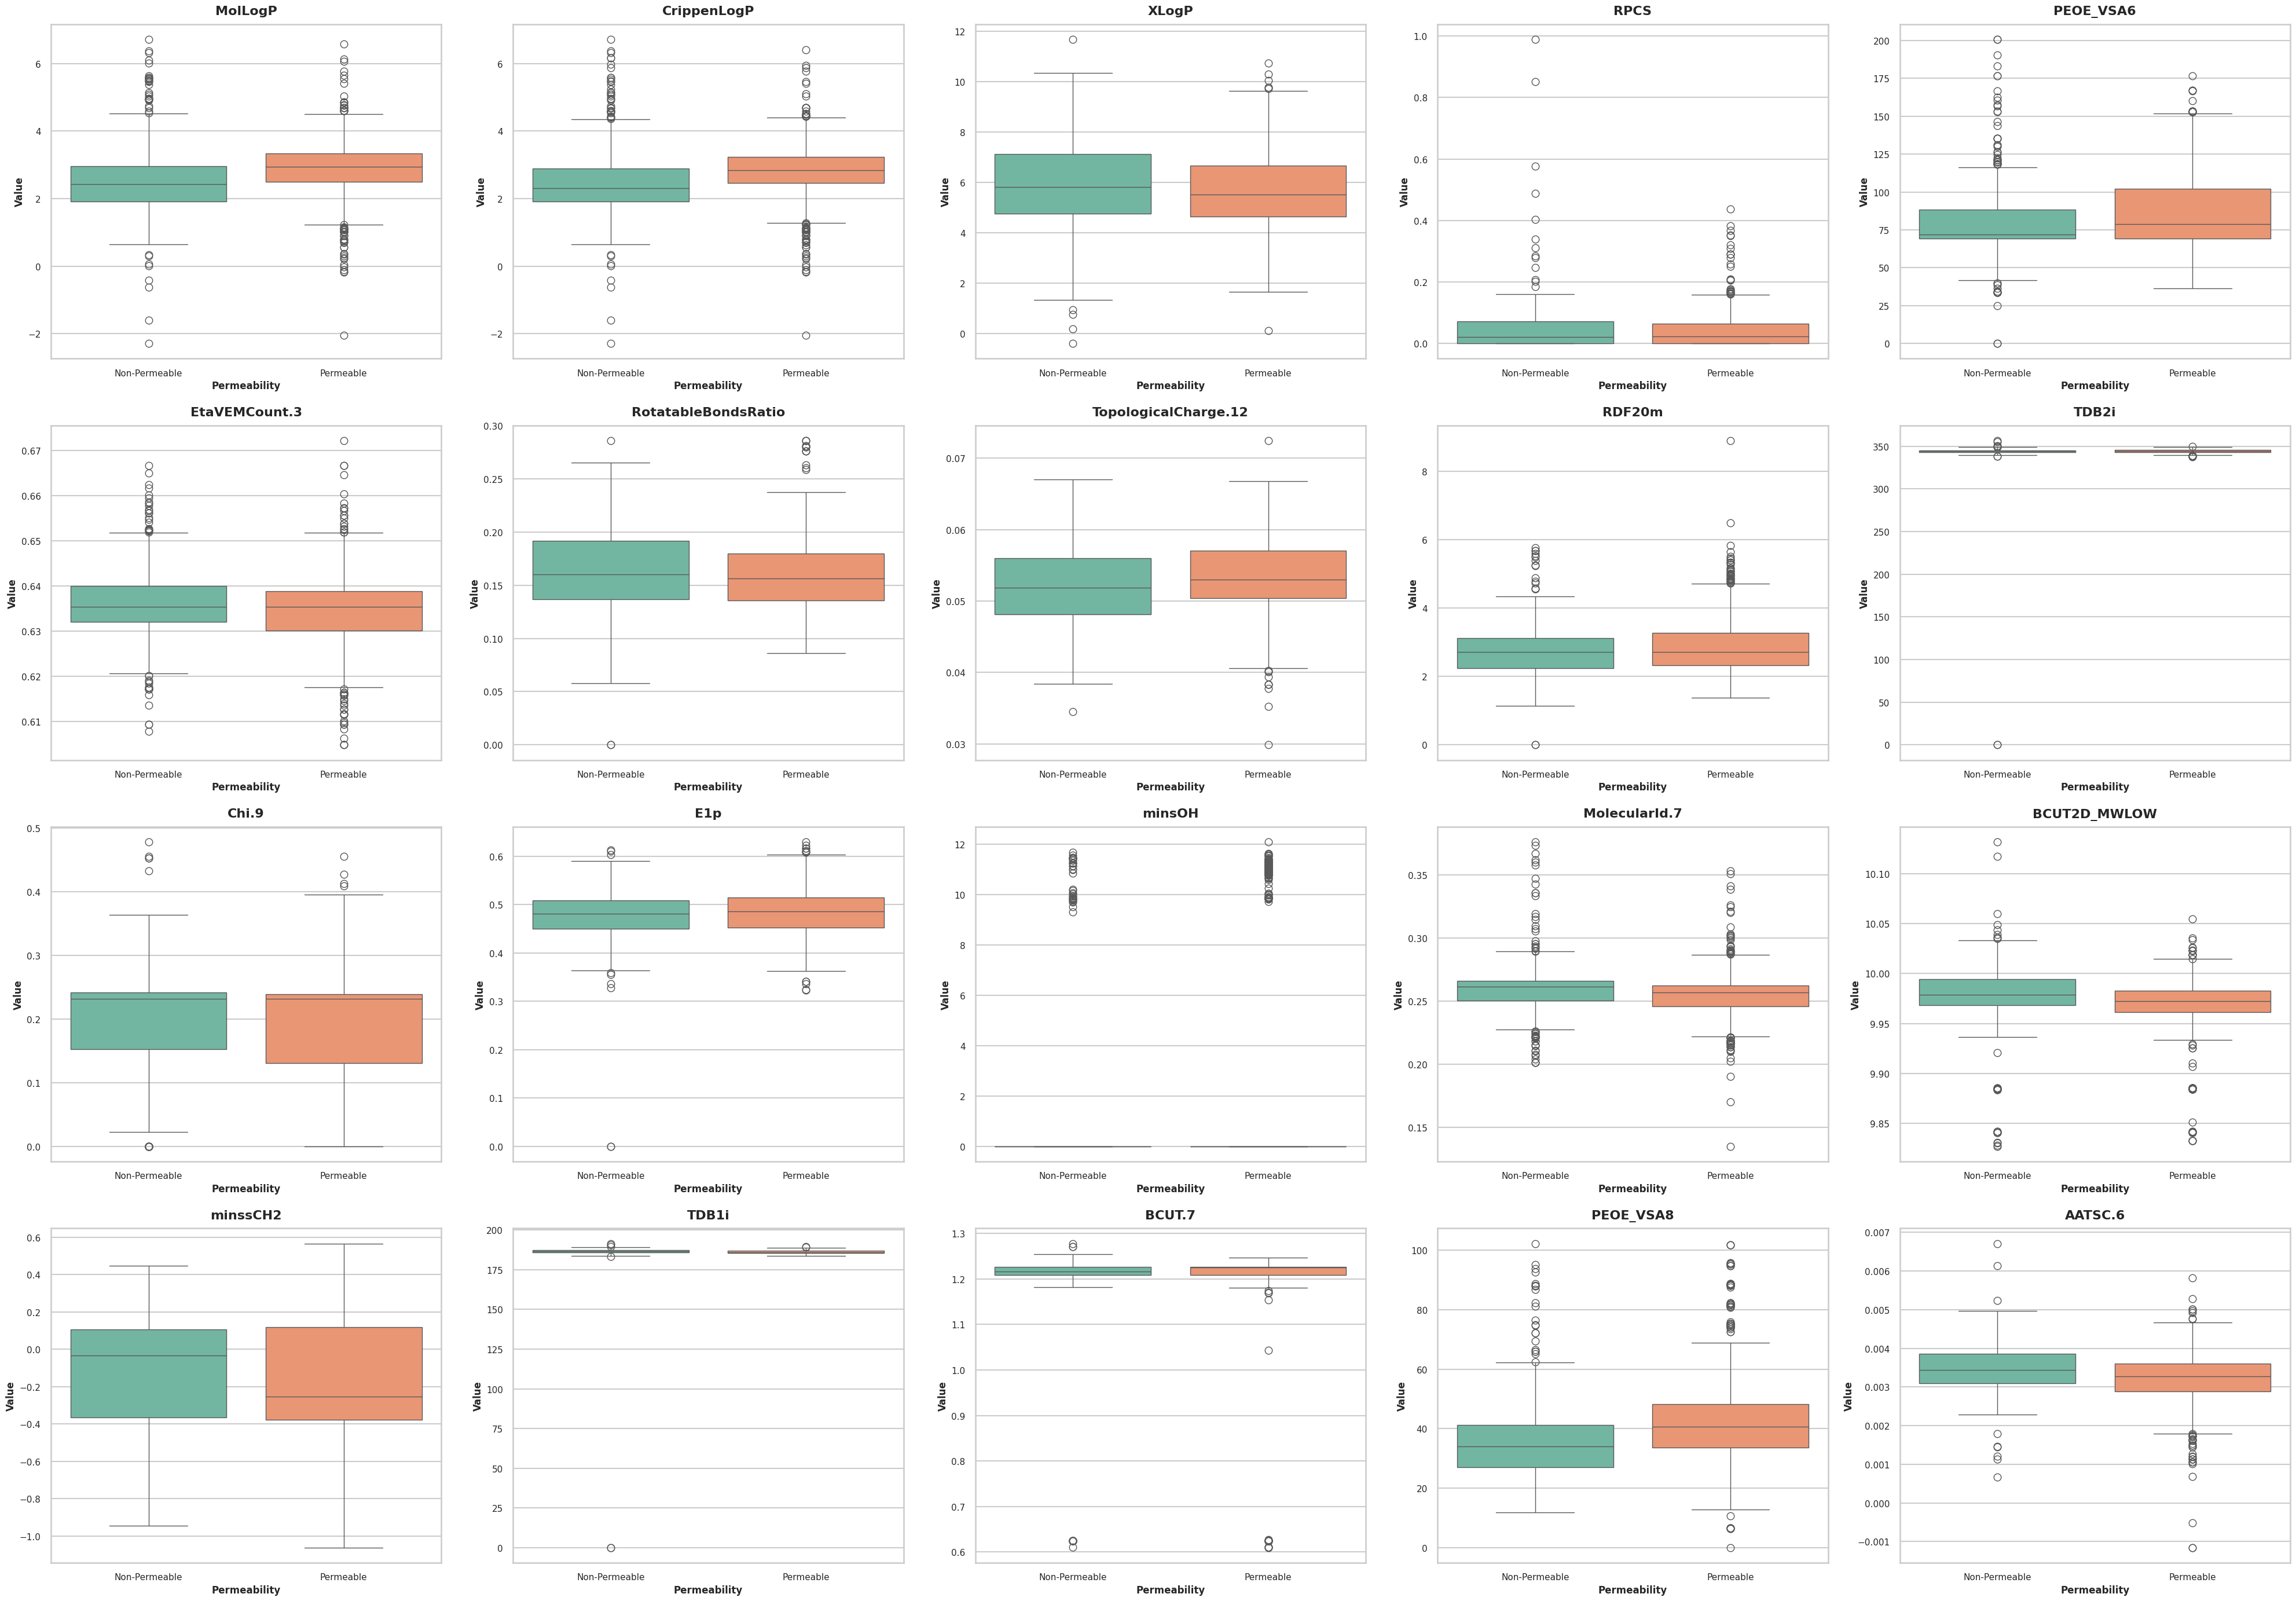

In [20]:
boxplots_diff_labels(test_df_labeled, feature_cols_test, label_col='Label', save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/desc_test_box_plot.png')


Top Features Correlation with Permeability by Label:

             Feature  Corr_Label_0  Corr_Label_1
             MolLogP     -0.001775     -0.130221
         CrippenLogP     -0.035084     -0.087657
               XLogP     -0.029823      0.015077
                RPCS     -0.070527     -0.088749
           PEOE_VSA6      0.065622      0.204192
       EtaVEMCount.3      0.073291     -0.187898
 RotatableBondsRatio     -0.171860     -0.022562
TopologicalCharge.12     -0.073619      0.267106
              RDF20m     -0.102410      0.375990
               TDB2i     -0.010183      0.220517
               Chi.9      0.249646     -0.513397
                 E1p      0.099300      0.093218
              minsOH     -0.074532      0.536363
       MolecularId.7     -0.058332      0.090135
        BCUT2D_MWLOW     -0.005485     -0.172738
            minssCH2      0.112056     -0.270961
               TDB1i     -0.011148      0.069767
              BCUT.7      0.095819      0.004516
           PEO

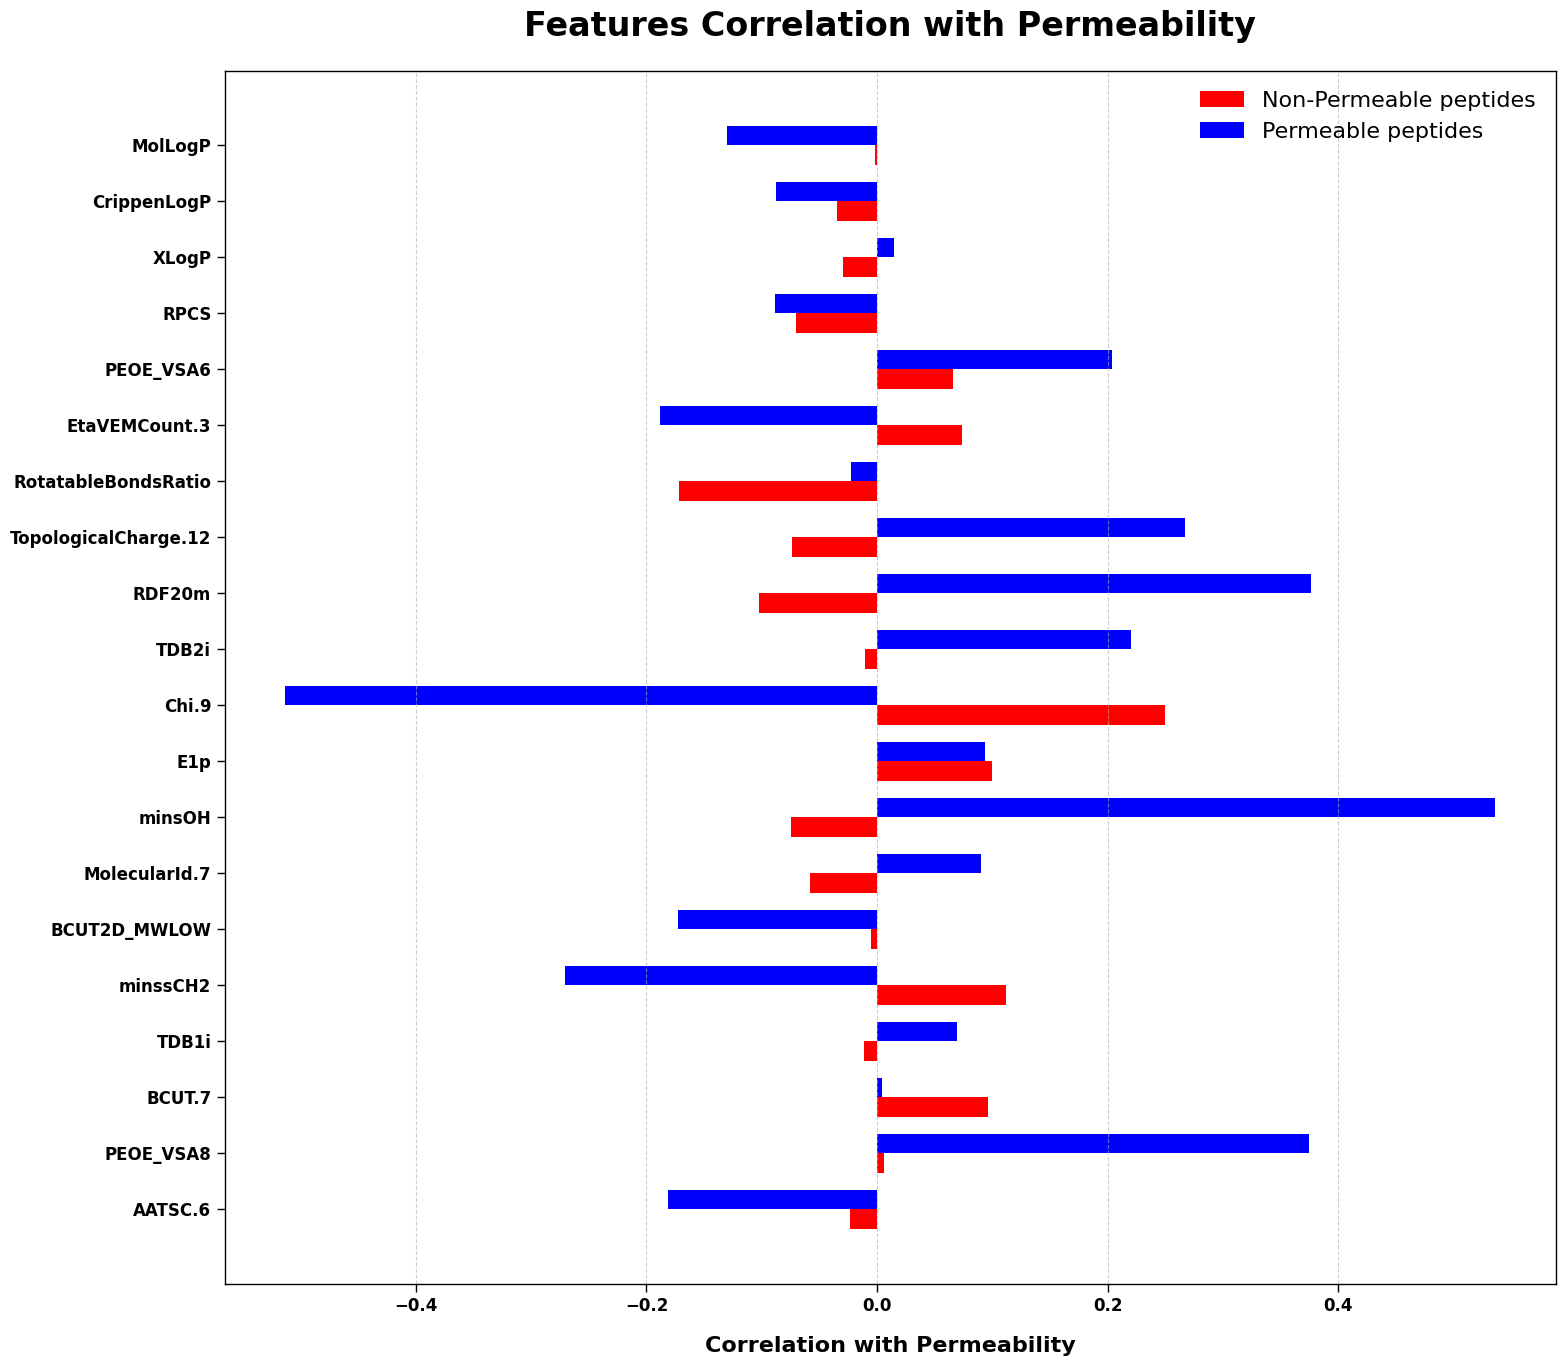

In [21]:
lgb_top_features_list = lgb_top_features_all['Feature'].to_list()

corr_df = plot_top_feature_correlations(
    test_df_labeled,
    label_col='Label',
    permeability_col='Permeability',
    top_desc_features=lgb_top_features_list,
    save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/desc_test_corr_plot.png'
)

In [22]:
ttest_df_test = ttest_feature_tests(test_df_labeled, label_col='Label', feature_cols=feature_cols_test, save_path = '/home/users/akshay/PCPpred/PAMPA/Results/feature_analysis/pampa_ttest_test.csv')
print(ttest_df_test)

Feature: MolLogP
T-Statistic: -4.9064, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: CrippenLogP
T-Statistic: -4.6336, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: XLogP
T-Statistic: 2.2031, P-Value: 0.0279
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: RPCS
T-Statistic: 1.9155, P-Value: 0.0559
Result: Fail to reject the null hypothesis - no significant difference between the two groups.

Feature: PEOE_VSA6
T-Statistic: -4.1700, P-Value: 0.0000
Result: Reject the null hypothesis - significant difference between the two groups.

Feature: EtaVEMCount.3
T-Statistic: 1.5736, P-Value: 0.1160
Result: Fail to reject the null hypothesis - no significant difference between the two groups.

Feature: RotatableBondsRatio
T-Statistic: 2.5620, P-Value: 0.0106
Result: Reject the null hypothesis - significant difference between 